# 05 — End-to-End Real-World EDA: Titanic Dataset
**Preetham's Seaborn Mastery Series**

This capstone notebook demonstrates how to combine Seaborn's entire suite of visualization tools into a comprehensive, real-world Exploratory Data Analysis (EDA) pipeline and analytical dashboard.

### EDA Workflow & Contents:
1. **Dataset Loading & Structural Inspection**
2. **Data Cleaning & Smart Imputation**
3. **Advanced Feature Engineering (Title, Family Size, IsAlone, Age Group)**
4. **Univariate Distribution Analysis**
5. **Bivariate & Group Demographics Survival Analysis**
6. **Multivariate Intersectional Facet Analysis (`FacetGrid` & `catplot`)**
7. **Statistical Correlation & Logistic Regression Modeling**
8. **Final Executive Summary Dashboard Layout**
9. **Key Analytical Insights & Findings**


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid")
%matplotlib inline

# Load raw Titanic dataset from Seaborn repository
titanic_raw = sns.load_dataset("titanic")

print("Dataset Dimensions:", titanic_raw.shape)
print("First 5 Rows:")
print(titanic_raw.head())
print("Data Schema & Missing Values:")
print(titanic_raw.isnull().sum())


Dataset Dimensions: (891, 15)
First 5 Rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
Data Schema & Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked    

## 1. Data Cleaning & Smart Imputation Strategy

- Impute missing `age` values using the median age within passenger class and sex subgroups.
- Impute missing `embarked` values using the statistical mode ('S').
- Extract `deck` letter from `cabin` information.


In [2]:
titanic = titanic_raw.copy()

# Smart Imputation for Age based on Pclass and Sex medians
titanic['age'] = titanic.groupby(['pclass', 'sex'])['age'].transform(lambda x: x.fillna(x.median()))

# Impute Embarked mode
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic['embark_town'] = titanic['embark_town'].fillna(titanic['embark_town'].mode()[0])

# Extract Deck from Cabin
titanic['deck'] = titanic['deck'].astype(str).replace('nan', 'Unknown')

print("Post-Cleaning Missing Values Count:")
print(titanic[['age', 'embarked', 'deck']].isnull().sum())


Post-Cleaning Missing Values Count:
age         0
embarked    0
deck        0
dtype: int64


## 2. Feature Engineering

We create informative engineered features:
1. `family_size` = `sibsp` + `parch` + 1
2. `is_alone` = Binary indicator if `family_size` == 1
3. `fare_category` = Binned quantile categories for ticket fare
4. `age_group` = Categorical age brackets (`Child`, `Teen`, `Adult`, `Senior`)


In [3]:
# 1. Family Size & IsAlone
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1
titanic['is_alone'] = (titanic['family_size'] == 1).astype(int)

# 2. Age Groups
titanic['age_group'] = pd.cut(
    titanic['age'],
    bins=[0, 12, 18, 50, 100],
    labels=['Child', 'Teen', 'Adult', 'Senior']
)

# 3. Fare Quantiles
titanic['fare_category'] = pd.qcut(
    titanic['fare'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

print("Engineered Features Sample:")
print(titanic[['survived', 'family_size', 'is_alone', 'age_group', 'fare_category']].head())


Engineered Features Sample:
   survived  family_size  is_alone age_group fare_category
0         0            2         0     Adult           Low
1         1            2         0     Adult     Very High
2         1            1         1     Adult        Medium
3         1            2         0     Adult     Very High
4         0            1         1     Adult        Medium


## 3. Univariate Distributions: Passenger Demographics & Survival Base Rates

Let's examine overall survival proportion, passenger class split, age distribution, and fare distribution.


C:\Users\praveen\AppData\Local\Temp\ipykernel_15012\2999751165.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=titanic, x="survived", palette="Set2", ax=axes[0, 0])
C:\Users\praveen\AppData\Local\Temp\ipykernel_15012\2999751165.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(["Perished", "Survived"])
C:\Users\praveen\AppData\Local\Temp\ipykernel_15012\2999751165.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=titanic, x="pclass", palette="crest", ax=axes[0, 1])


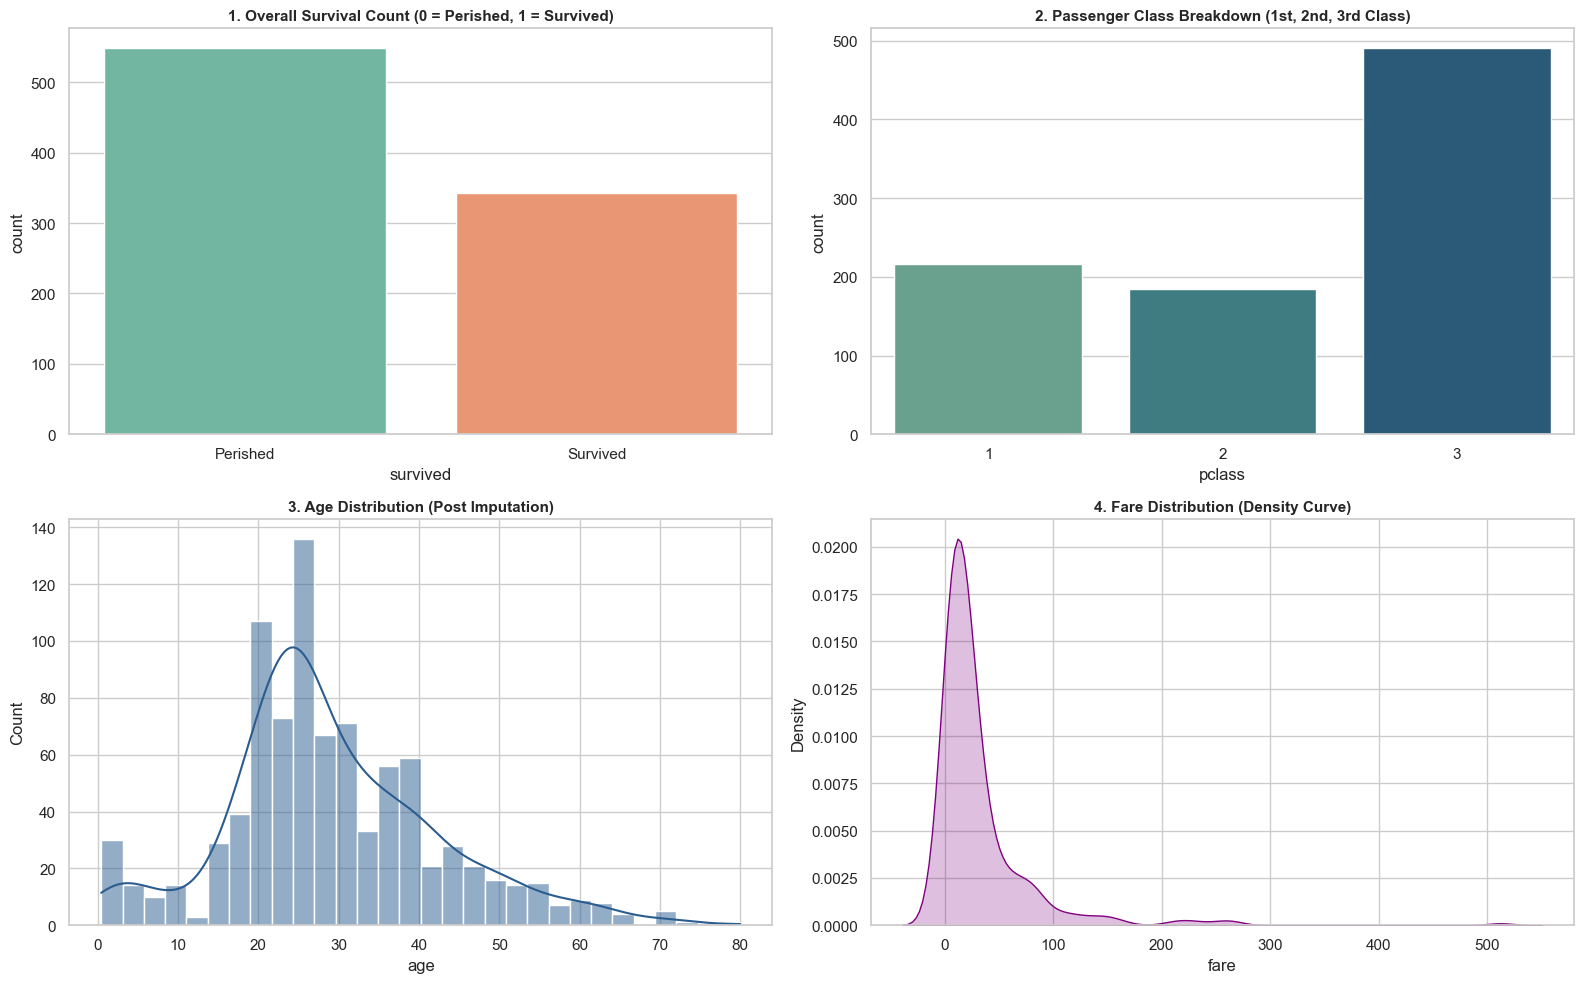

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Overall Survival Rate (Countplot with percentages)
sns.countplot(data=titanic, x="survived", palette="Set2", ax=axes[0, 0])
axes[0, 0].set_title("1. Overall Survival Count (0 = Perished, 1 = Survived)", fontsize=11, fontweight="bold")
axes[0, 0].set_xticklabels(["Perished", "Survived"])

# 2. Passenger Class Distribution
sns.countplot(data=titanic, x="pclass", palette="crest", ax=axes[0, 1])
axes[0, 1].set_title("2. Passenger Class Breakdown (1st, 2nd, 3rd Class)", fontsize=11, fontweight="bold")

# 3. Age Distribution (Histplot + KDE)
sns.histplot(data=titanic, x="age", kde=True, bins=30, color="#2b5c8f", ax=axes[1, 0])
axes[1, 0].set_title("3. Age Distribution (Post Imputation)", fontsize=11, fontweight="bold")

# 4. Fare Distribution (KDE Plot log scale)
sns.kdeplot(data=titanic, x="fare", fill=True, color="purple", ax=axes[1, 1])
axes[1, 1].set_title("4. Fare Distribution (Density Curve)", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


## 4. Bivariate Demographics & Intersectional Survival Analysis

Next, we analyze how survival rates vary across key demographic factors:
- Survival by Gender & Class
- Survival by Age Group & Family Size
- Survival by Embarkation Port


C:\Users\praveen\AppData\Local\Temp\ipykernel_15012\1678537917.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


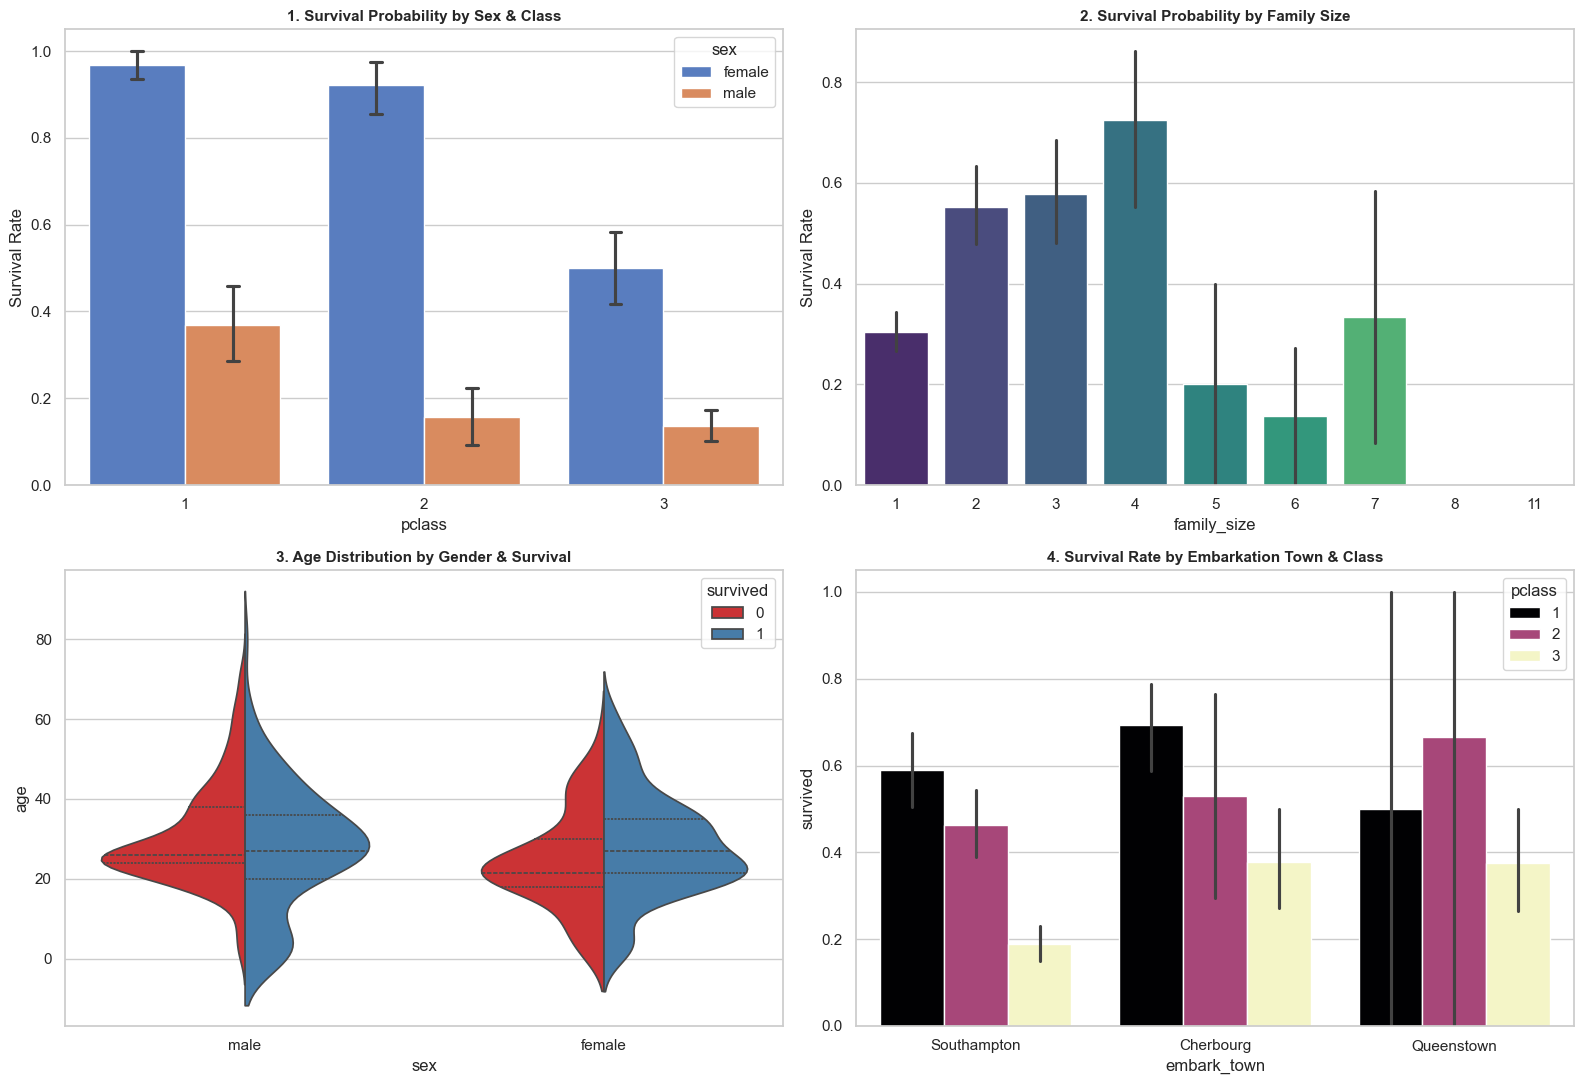

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Survival Probability by Gender & Class
sns.barplot(
    data=titanic,
    x="pclass",
    y="survived",
    hue="sex",
    palette="muted",
    capsize=0.1,
    ax=axes[0, 0]
)
axes[0, 0].set_title("1. Survival Probability by Sex & Class", fontsize=11, fontweight="bold")
axes[0, 0].set_ylabel("Survival Rate")

# 2. Survival Rate by Family Size
sns.barplot(
    data=titanic,
    x="family_size",
    y="survived",
    palette="viridis",
    ax=axes[0, 1]
)
axes[0, 1].set_title("2. Survival Probability by Family Size", fontsize=11, fontweight="bold")
axes[0, 1].set_ylabel("Survival Rate")

# 3. Violin Plot: Age Distribution by Survival Status & Gender
sns.violinplot(
    data=titanic,
    x="sex",
    y="age",
    hue="survived",
    split=True,
    inner="quartile",
    palette="Set1",
    ax=axes[1, 0]
)
axes[1, 0].set_title("3. Age Distribution by Gender & Survival", fontsize=11, fontweight="bold")

# 4. Survival Probability by Embarkation Town & Class
sns.barplot(
    data=titanic,
    x="embark_town",
    y="survived",
    hue="pclass",
    palette="magma",
    ax=axes[1, 1]
)
axes[1, 1].set_title("4. Survival Rate by Embarkation Town & Class", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


## 5. Multi-Facet Distribution Analysis (`FacetGrid` & `scatterplot`)

To uncover subtle relationships, we map Age vs Fare colored by Survival status across Passenger Class columns and Sex rows.


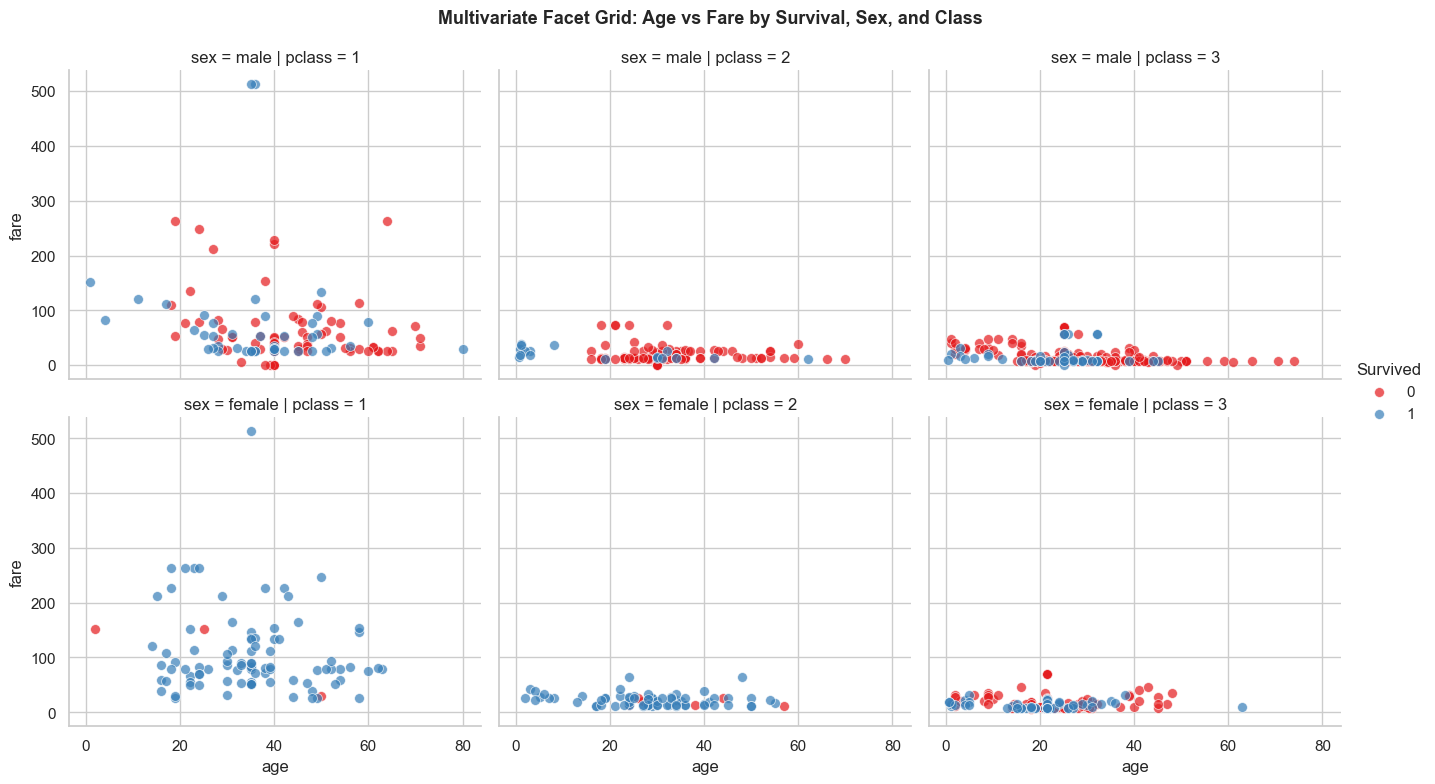

In [6]:
g = sns.FacetGrid(titanic, col="pclass", row="sex", hue="survived", palette="Set1", height=3.8, aspect=1.2)
g.map(sns.scatterplot, "age", "fare", alpha=0.7, s=50)
g.add_legend(title="Survived")
g.fig.suptitle("Multivariate Facet Grid: Age vs Fare by Survival, Sex, and Class", y=1.03, fontsize=13, fontweight="bold")
plt.show()


## 6. Statistical Correlation Heatmap & Logistic Model Fitting

Let's examine linear correlation across all numeric variables and fit a logistic regression curve for survival probability versus age across classes.


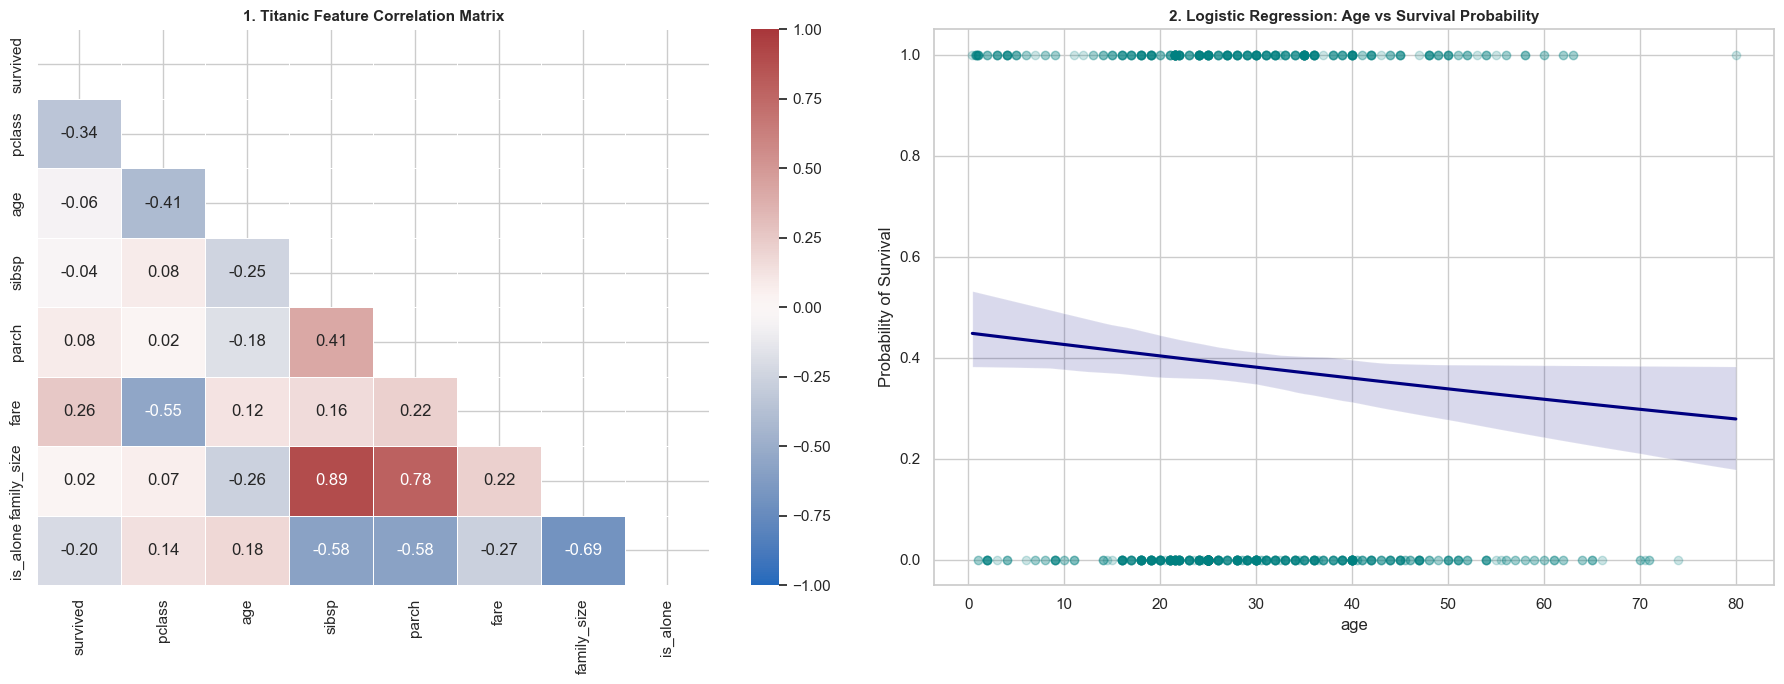

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Numeric Correlation Heatmap
numeric_titanic = titanic.select_dtypes(include="number")
corr = numeric_titanic.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    mask=mask,
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title("1. Titanic Feature Correlation Matrix", fontsize=11, fontweight="bold")

# 2. Logistic Regression Fit: Survival Probability vs Age
sns.regplot(
    data=titanic,
    x="age",
    y="survived",
    logistic=True,
    n_boot=100,
    color="navy",
    scatter_kws={"alpha": 0.2, "color": "teal"},
    ax=axes[1]
)
axes[1].set_title("2. Logistic Regression: Age vs Survival Probability", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Probability of Survival")

plt.tight_layout()
plt.show()


## 7. Executive Summary Dashboard Layout

Synthesizing all key insights into a clean 4-panel executive visualization summary dashboard.


C:\Users\praveen\AppData\Local\Temp\ipykernel_15012\3470858277.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(["With Family", "Traveling Alone"])


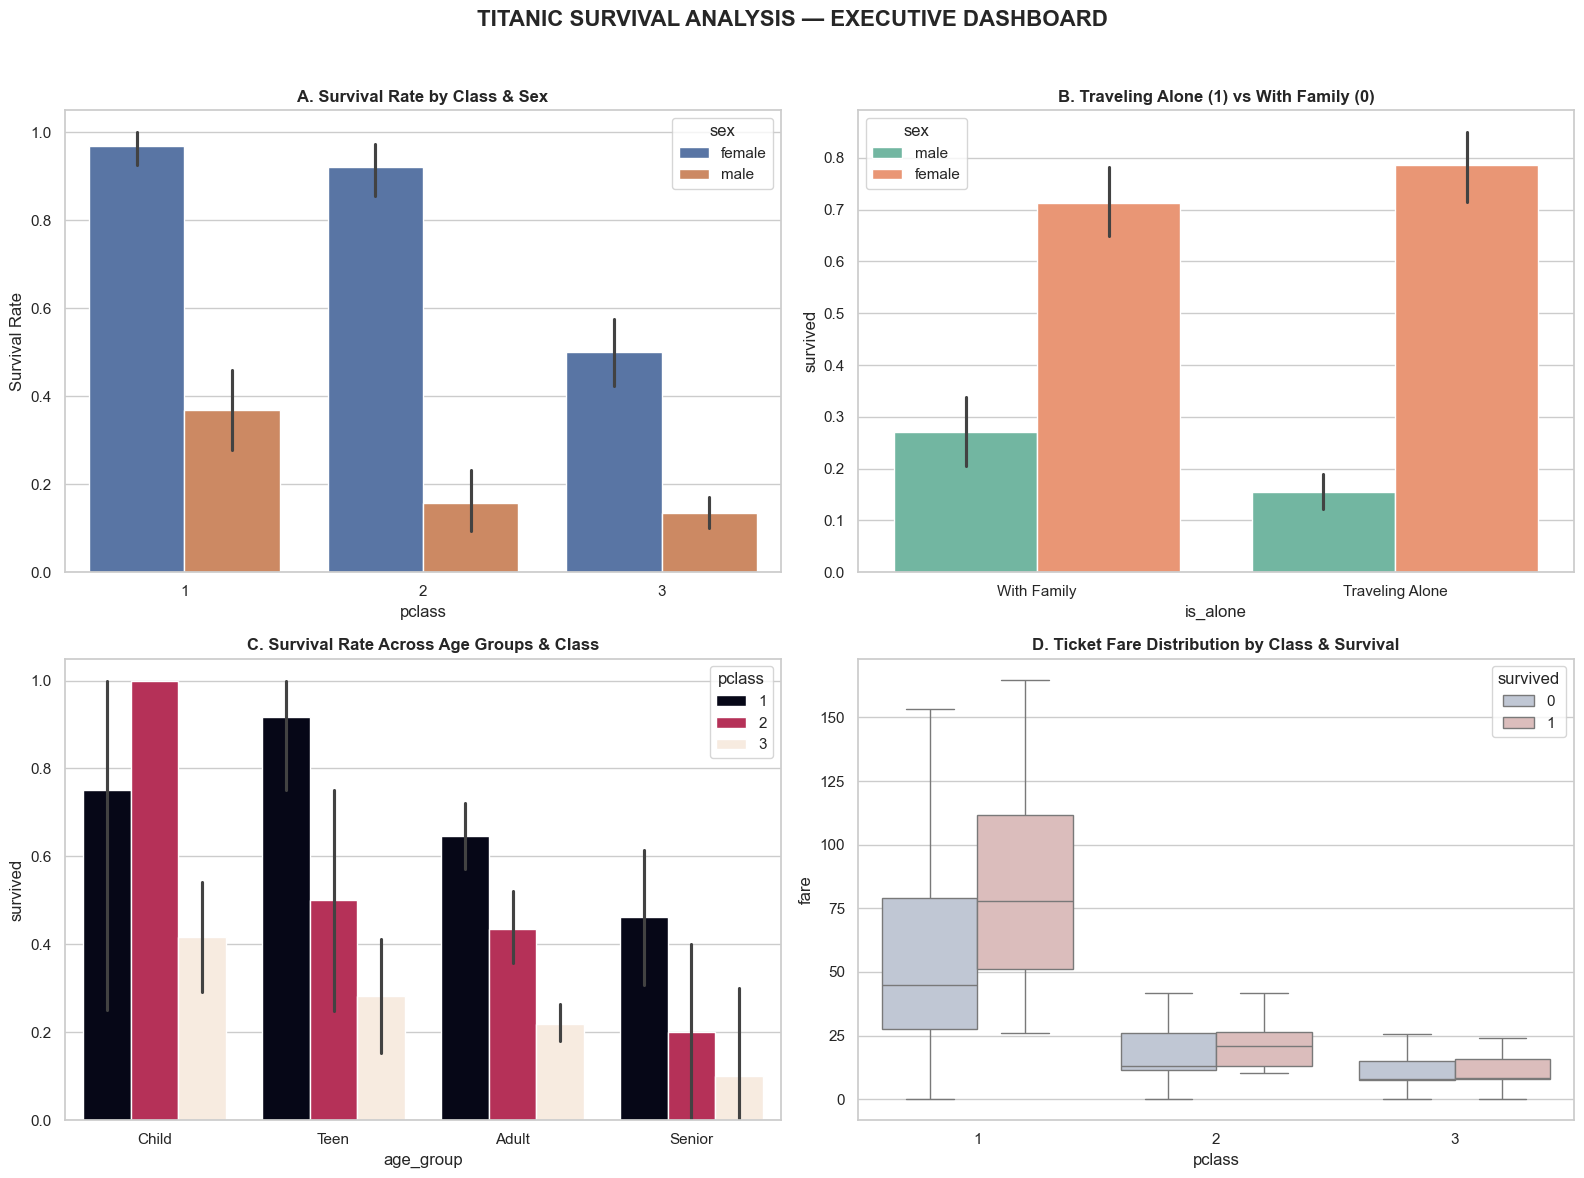

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("TITANIC SURVIVAL ANALYSIS — EXECUTIVE DASHBOARD", fontsize=16, fontweight="bold", y=0.98)

# Panel 1: Sex & Class Survival Matrix
sns.barplot(data=titanic, x="pclass", y="survived", hue="sex", palette="deep", ax=axes[0, 0])
axes[0, 0].set_title("A. Survival Rate by Class & Sex", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Survival Rate")

# Panel 2: Alone vs Family Survival Difference
sns.barplot(data=titanic, x="is_alone", y="survived", hue="sex", palette="Set2", ax=axes[0, 1])
axes[0, 1].set_title("B. Traveling Alone (1) vs With Family (0)", fontsize=12, fontweight="bold")
axes[0, 1].set_xticklabels(["With Family", "Traveling Alone"])

# Panel 3: Age Group Survival Rate
sns.barplot(data=titanic, x="age_group", y="survived", hue="pclass", palette="rocket", ax=axes[1, 0])
axes[1, 0].set_title("C. Survival Rate Across Age Groups & Class", fontsize=12, fontweight="bold")

# Panel 4: Fare Category Boxplot by Class
sns.boxplot(data=titanic, x="pclass", y="fare", hue="survived", palette="vlag", showfliers=False, ax=axes[1, 1])
axes[1, 1].set_title("D. Ticket Fare Distribution by Class & Survival", fontsize=12, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 8. Key Analytical Findings & Summary

1. **Gender Disparity**: Female survival rate was ~74%, compared to ~19% for males, reflecting the "women and children first" protocol.
2. **Socioeconomic Status**: 1st Class passengers had a ~63% survival rate, whereas 3rd Class passengers had only ~24% survival rate.
3. **Family Effects**: Passengers traveling in small families (2–4 members) had significantly higher survival rates than individuals traveling alone.
4. **Children Priority**: Children (< 12 years old) had the highest survival probabilities across all age brackets.
